This is a customized code of wagenaars code given in the link:
https://github.com/wagenaartje/pinn4hcf

In [ ]:
import torch
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

torch.manual_seed(5)
np.random.seed(5)

# Physical constants
gamma = 1.4
r_inf = 1.0
p_inf = 1.0
M_inf = 2.0
v_inf = 0.0
u_inf = math.sqrt(gamma*p_inf/r_inf)*M_inf

# Geometry
x_min = 0.0
x_max = 2
y_min = 0.0
y_max = 2.0
w_angle = math.radians(10)
w_start = 1

# Hyperparameters
num_ib = 750
num_r = 10000


''' Partial differential equations '''
def pde (state, coords):
    # Coordinates
    x = coords[0]
    y = coords[1]

    # State
    r = state[:, [0]]
    p = state[:, [1]]
    u = state[:, [2]]
    v = state[:, [3]]
    viscosity = state[:, [4]]**2
    # viscosity = 0
    
    # ===== First derivatives =====

    rho_x = torch.autograd.grad(r, x, torch.ones_like(r), create_graph=True)[0]
    rho_y = torch.autograd.grad(r, y, torch.ones_like(r), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]

    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]
    def laplacian(U):
        U_x  = torch.autograd.grad(U, x, torch.ones_like(U), create_graph=True)[0]
        U_xx = torch.autograd.grad(U_x, x, torch.ones_like(U_x), create_graph=True)[0]
        U_y  = torch.autograd.grad(U, y, torch.ones_like(U), create_graph=True)[0]
        U_yy = torch.autograd.grad(U_y, y, torch.ones_like(U_y), create_graph=True)[0]
        return U_xx + U_yy

    rho_lap = laplacian(r)
    u_lap   = laplacian(u)
    v_lap   = laplacian(v)
    p_lap   = laplacian(p)

        # Continuity
    r1 = u*rho_x + v*rho_y + r*(u_x + v_y) - viscosity * rho_lap
    r2 = r*(u*u_x + v*u_y) + p_x          - viscosity * u_lap
    r3 = r*(u*v_x + v*v_y) + p_y          - viscosity * v_lap
    r4 = u*p_x + v*p_y + gamma*p*(u_x + v_y) - viscosity * p_lap

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(r1),create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(r1),create_graph=True)[0]

    d=0.12*(abs(u_x)-u_x)  + 1+0.12*(abs(v_y)-v_y)

    return r1/d, r2/d, r3/d, r4/d

''' Model definition '''
# Generator
class Generator (torch.nn.Module):
    def __init__(self):
        super().__init__()
        t1=15

        torch.manual_seed(0)
        self.map = torch.nn.Sequential(
            torch.nn.Linear(2, t1), torch.nn.Tanh(),
            torch.nn.Linear(t1, t1), torch.nn.Tanh(),
            torch.nn.Linear(t1, t1), torch.nn.Tanh(),
            torch.nn.Linear(t1, t1), torch.nn.Tanh(),
            torch.nn.Linear(t1, 5)
        )

    def forward (self, a: tuple) -> torch.Tensor:
        # Force positive density and pressure
        res = self.map(torch.cat(a, 1))
        res[:,0] = torch.exp(res[:,0])
        res[:,1] = torch.exp(res[:,1])

        return res

def loss_slip (coords, thetas):
    for x in coords: x.requires_grad = True
    state = generator(coords)

    u = state[:, [2]]
    v = state[:, [3]]
    
    cos = torch.cos(thetas)
    sin = torch.sin(thetas)

    u_angle = u * cos + v * sin

    fb = (u_angle**2).mean()
    
    return fb


# Loss function for PDE
def loss_pde (coords):
    global mse_pde, res_r, res_p, res_u, res_v, mse_v

    for x in coords: x.requires_grad = True
    state = generator(coords)
    r1, r2, r3, r4 = pde(state, coords)


    f = (r1**2).mean() + \
        (r2**2).mean() + \
        (r3**2).mean() + \
        (r4**2).mean()
    
    mse_pde = f.item()
    res_r = (r1**2).mean().item()
    res_p = (r2**2).mean().item()
    res_u = (r3**2).mean().item()
    res_v = (r4**2).mean().item()

    f_v = (state[:,[4]]**2).mean()
    mse_v = f_v.item()
        
    return f, f_v

def loss_slip (coords, thetas):
    for x in coords: x.requires_grad = True
    state = generator(coords)
    x = coords[0]
    y = coords[1]

    r = state[:,[0]]
    p = state[:,[1]]
    u = state[:,[2]]
    v = state[:,[3]]
    
    cos = torch.cos(thetas)
    sin = torch.sin(thetas)
    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]

    cos = torch.cos(thetas)
    sin = torch.sin(thetas)

    p_theta = p_x * cos + p_y * sin
    u_theta = u * cos + v * sin

    loss = (u_theta**2).mean() #+ \
            # (p_theta**2).mean()
            # (r_theta**2).mean()
    
    return loss

def loss_inlet (x_bc, u_bc):
    u_pred = generator(x_bc)
    
    loss = ((u_pred[:,0] - u_bc[0])**2).mean() + \
           ((u_pred[:,1] - u_bc[1])**2).mean() + \
           ((u_pred[:,2] - u_bc[2])**2).mean() + \
           ((u_pred[:,3] - u_bc[3])**2).mean()
    
    return loss
def loss_outlet(coords):
    for x in coords: 
        x.requires_grad = True
        
    state = generator(coords)

    x1 = coords[0]
    
    rho = state[:, [0]]
    p   = state[:, [1]]
    u   = state[:, [2]]
    v   = state[:, [3]]

    rho_x = torch.autograd.grad(rho, x1, torch.ones_like(rho), create_graph=True)[0]
    p_x   = torch.autograd.grad(p,   x1, torch.ones_like(p),   create_graph=True)[0]
    u_x   = torch.autograd.grad(u,   x1, torch.ones_like(u),   create_graph=True)[0]
    v_x   = torch.autograd.grad(v,   x1, torch.ones_like(v),   create_graph=True)[0]

    loss = (rho_x**2).mean() + \
           (p_x**2).mean()   + \
           (u_x**2).mean()   + \
           (v_x**2).mean()

    return loss
def loss_sym (coords, thetas):
    for x in coords: x.requires_grad = True
    state = generator(coords)
    x1 = coords[0]
    y1 = coords[1]


    u = state[:, [2]]
    v = state[:, [3]]
    p=state[:, [1]]
    p_x = torch.autograd.grad(p, x1, grad_outputs=torch.ones_like(p),create_graph=True)[0]
    p_y = torch.autograd.grad(p, y1, grad_outputs=torch.ones_like(p),create_graph=True)[0]
    cos = torch.cos(thetas)
    sin = torch.sin(thetas)
    pl=p_x+p_y

    fb =(v**2).mean()
    
    return fb
def mass_flux_boundary(coords, nx, ny):
    x, y = coords
    state = generator((x, y))
    
    rho = state[:, 0]
    u   = state[:, 2]
    v   = state[:, 3]
    
    flux = rho * (u * nx + v * ny)
    return flux.sum()

def loss_mass_conservation():

    m_in = mass_flux_boundary(x_l, nx=-1.0, ny=0.0)
    m_out = mass_flux_boundary(x_o, nx=1.0, ny=0.0)
    m_top = mass_flux_boundary(x_t, nx=0.0, ny=1.0)
    m_bottom = mass_flux_boundary(x_b, nx=0.0, ny=-1.0)

    nx_w = math.sin(w_angle)
    ny_w = -math.cos(w_angle)
    m_wedge = mass_flux_boundary(x_w, nx=nx_w, ny=ny_w)

    net_flux = m_in + m_out + m_top + m_bottom + m_wedge

    rel_defect = net_flux / (m_in.abs() + 1e-8)

    return rel_defect**2

def evaluate ():
    global mse_bc
    optimizer.zero_grad()                     

    loss_r, loss_v = loss_pde(x_r)        
    loss_b = loss_sym(x_b, t_b)
    loss_l = loss_inlet(x_l, u_l)
    loss_c = loss_slip(x_w, t_w) 
    loss_bc = loss_c + loss_l + loss_b  

    loss_mass = loss_mass_conservation()
    loss = loss_r + 1 * loss_bc + 1e-2 * loss_v+ 1e-0* loss_mass

    mse_bc = loss_bc.item()

    loss.backward()

    return loss

if __name__ == '__main__':
    # Set up hardware 
    device = torch.device('cuda')
    torch.set_default_dtype(torch.float32)



    x_l = torch.full((num_ib, 1), x_min, device=device)
    y_l = torch.linspace(y_min, y_max, num_ib, device=device).reshape(-1,1)

    u_l = (r_inf, p_inf, u_inf, v_inf)

    # Top boundary
    x_t = torch.linspace(x_min, x_max, num_ib, device=device).reshape(-1,1)
    y_t = torch.full((num_ib, 1), y_max, device=device)

    t_t = torch.full((num_ib,1), -torch.pi/2,device=device)

    # Bottom boundary
    x_b = torch.linspace(x_min,w_start, num_ib+1, device=device)[:-1].reshape(-1,1)
    y_b = torch.full((num_ib, 1), y_min, device=device)

    t_b = torch.full((num_ib,1), torch.pi/2, device=device)

    # Wedge boundary
    x_w = torch.linspace(w_start, x_max, num_ib, device=device).reshape(-1,1)
    geom = lambda x:  (x-w_start)*math.tan(w_angle)
    y_w = y_min +geom(x_w)

    t_w = torch.full((num_ib,1), torch.pi/2 + w_angle, device=device)
    # Outlet boundary (right side)  
    x_o = torch.full((num_ib, 1), x_max, device=device).float()
    y_o = torch.linspace(y_min, y_max, num_ib, device=device).reshape(-1,1)
    x_o = (x_o, y_o)
    
    # Convert to tuples
    x_l = (x_l, y_l)
    x_t = (x_t, y_t)
    x_b = (x_b, y_b)
    x_w = (x_w, y_w)

    with open('fluent_mesh.dat', 'r') as file:
        lines = file.readlines()

# Skip the first line and split each line into a list of elements
    data = [line.strip().split() for line in lines[1:]]

# Convert the list of lists to a NumPy array
    data_in = np.array(data, dtype=float)  # Use dtype=float if your data is numeric

    x_in=data_in[:,1]
    y_in=data_in[:,2]
    x_test1 = torch.tensor(x_in, device=device, dtype=torch.float32)
    y_test1 = torch.tensor(y_in, device=device, dtype=torch.float32)
    x_test1=torch.reshape(x_test1,(-1,1))
    y_test1=torch.reshape(y_test1,(-1,1))
    x_test = (x_test1, y_test1)
    x_r=x_test

    # Set up models and optimizer
    generator = Generator().to(device)
    optimizer = torch.optim.LBFGS(generator.parameters(),lr=0.1)



    # Start looping
    epoch = 0
    start_time = time.time()
    lowest_loss = None
    lowest_loss_epoch = 0

    for i in range(1001):
        epoch_start_time = time.time() 

        # Optimize loss function
        if epoch > 0:
            loss = optimizer.step(evaluate)
        else:
            loss = evaluate()

        # Calculate L2 error
        

        # Print status
        print(f'Epoch: {epoch:4d} - Time: {time.time() - epoch_start_time:.2f} - MSE_r: {mse_pde:.2e} - MSE_v: {mse_v:.2e} - MSE_bc: {mse_bc:.2e} ')
        epoch += 1
        if mse_pde+mse_bc<1e-3:
                break

    u_pred = generator(x_test)    


Epoch:    0 - Time: 0.79 - MSE_r: 1.30e-02 - MSE_v: 5.68e-02 - MSE_bc: 5.22e+00 
Epoch:    1 - Time: 4.19 - MSE_r: 1.69e-03 - MSE_v: 1.09e-01 - MSE_bc: 2.45e+00 
Epoch:    2 - Time: 3.80 - MSE_r: 1.41e-02 - MSE_v: 2.06e-01 - MSE_bc: 9.65e-02 
Epoch:    3 - Time: 3.75 - MSE_r: 2.10e-02 - MSE_v: 9.12e-03 - MSE_bc: 4.30e-02 
Epoch:    4 - Time: 4.21 - MSE_r: 1.10e-02 - MSE_v: 5.10e-02 - MSE_bc: 2.59e-02 
Epoch:    5 - Time: 4.30 - MSE_r: 6.42e-03 - MSE_v: 1.91e-01 - MSE_bc: 1.52e-02 
Epoch:    6 - Time: 5.08 - MSE_r: 4.05e-03 - MSE_v: 1.43e-01 - MSE_bc: 1.32e-02 
Epoch:    7 - Time: 4.51 - MSE_r: 2.84e-03 - MSE_v: 6.74e-02 - MSE_bc: 9.74e-03 
Epoch:    8 - Time: 4.57 - MSE_r: 2.02e-03 - MSE_v: 6.91e-02 - MSE_bc: 8.63e-03 
Epoch:    9 - Time: 4.41 - MSE_r: 2.13e-03 - MSE_v: 6.32e-02 - MSE_bc: 7.28e-03 
Epoch:   10 - Time: 4.48 - MSE_r: 2.12e-03 - MSE_v: 4.53e-02 - MSE_bc: 5.98e-03 
Epoch:   11 - Time: 4.52 - MSE_r: 1.68e-03 - MSE_v: 3.91e-02 - MSE_bc: 5.44e-03 
Epoch:   12 - Time: 4.57 - M

In [2]:
r=u_pred[:,0]
p=u_pred[:,1]
u=u_pred[:,2]
v=u_pred[:,3]
x_test=torch.stack(x_test)
x_test=torch.reshape(x_test,(2,-1))
x_test=x_test.detach().cpu().numpy()
r=r.detach().cpu().numpy()
p=p.detach().cpu().numpy()
u=u.detach().cpu().numpy()
v=v.detach().cpu().numpy()
x_test1=x_test[0,:]
y_test1=x_test[1,:]

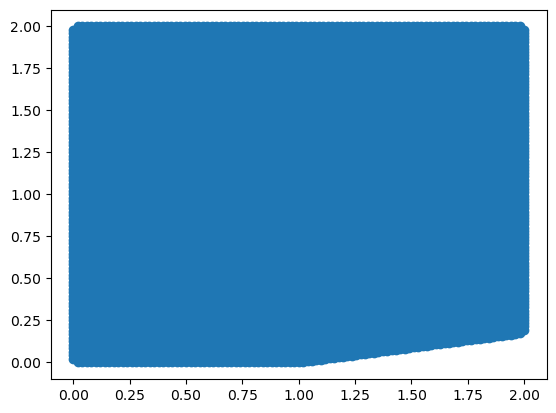

In [3]:
plt.scatter(x_test1,y_test1)

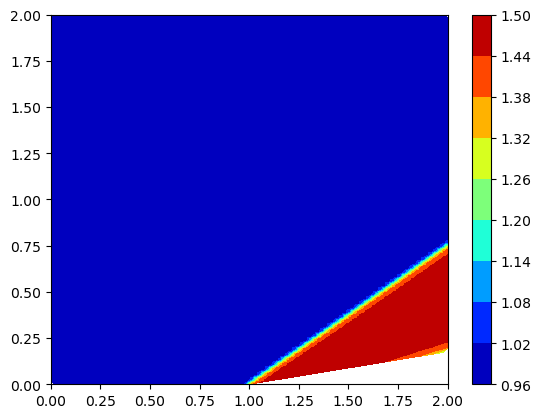

In [4]:
triang = Triangulation(x_test1, y_test1)
plt.tricontourf(triang, r, cmap='jet')
plt.colorbar()

In [5]:
data1=np.vstack([x_test1,y_test1,r,p,u,v])
data1=data1.T
np.savetxt('wedge_pinn_con.dat',data1)

In [6]:
# ============================================
# CONSERVATION CHECK FOR PINN SOLUTION
# ============================================


# Inlet (normal = -x)
m_in = mass_flux_boundary(x_l, nx=-1.0, ny=0.0).item()

# Outlet (normal = +x)
m_out = mass_flux_boundary(x_o, nx=1.0, ny=0.0).item() 

# Top (normal = +y)
m_top = mass_flux_boundary(x_t, nx=0.0, ny=1.0).item()

# Bottom wall (normal = -y)
m_bottom = mass_flux_boundary(x_b, nx=0.0, ny=-1.0).item()

# Wedge wall normal
nx_w = math.sin(w_angle)
ny_w = -math.cos(w_angle)

m_wedge = mass_flux_boundary(x_w, nx=nx_w, ny=ny_w).item()

net_flux = m_in + m_out + m_top + m_bottom + m_wedge

mass_defect = abs(net_flux) / abs(m_in)

print("Mass flux inlet :", m_in)
print("Mass flux outlet:", m_out)
print("Mass flux top   :", m_top)
print("Mass flux bottom:", m_bottom)
print("Mass flux wedge :", m_wedge)
print("Net flux        :", net_flux)
print("Mass defect     :", mass_defect)

Mass flux inlet : -1773.7381591796875
Mass flux outlet: 1780.8916015625
Mass flux top   : 0.11721308529376984
Mass flux bottom: -2.2757720947265625
Mass flux wedge : 1.011854887008667
Net flux        : 6.006738260388374
Mass defect     : 0.00338648533285564
